In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("movies.csv")

In [3]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 1.8 MB


In [5]:
df.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [6]:
# Dropping the rows with null values of score, votes, writer, country, runtime
df.dropna(subset=["score", "votes", "writer", "country", "runtime"], inplace=True)

In [7]:
df["rating"]

0               R
1               R
2              PG
3              PG
4               R
          ...    
7659    Not Rated
7660          NaN
7663          NaN
7664          NaN
7667          NaN
Name: rating, Length: 7657, dtype: str

In [8]:
df["rating"].value_counts()

rating
R            3694
PG-13        2111
PG           1252
Not Rated     282
G             153
Unrated        51
NC-17          23
TV-MA           9
TV-PG           4
X               3
Approved        1
TV-14           1
Name: count, dtype: int64

In [9]:
# Dropping the rows with null values of rating
df.dropna(subset=["rating"], inplace=True)

In [10]:
df.isna().sum()

name           0
rating         0
genre          0
year           0
released       0
score          0
votes          0
director       0
writer         0
star           0
country        0
budget      2109
gross        163
company       10
runtime        0
dtype: int64

In [11]:
# First checking whether there are any rows with budget or gross as zero
print(df[df["budget"] == 0])
print(df[df["gross"] == 0])

Empty DataFrame
Columns: [name, rating, genre, year, released, score, votes, director, writer, star, country, budget, gross, company, runtime]
Index: []
Empty DataFrame
Columns: [name, rating, genre, year, released, score, votes, director, writer, star, country, budget, gross, company, runtime]
Index: []


In [12]:
# Now filling the missing values in the dataset for budget
# First checking the distribution of the data
print(df["budget"].skew())

2.451176351890398


<Axes: xlabel='budget', ylabel='Count'>

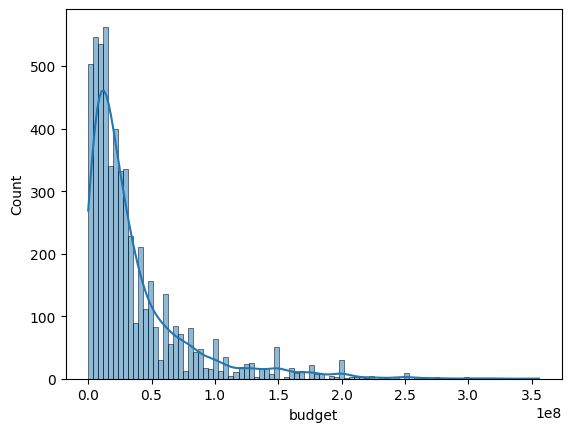

In [13]:
sns.histplot(df["budget"].dropna(), kde=True)

In [14]:
# As the graph and the skew function suggest the data in the budget column so we will use median to fill it
df["budget"] = df["budget"].fillna(df["budget"].median())

5.306827472423984


<Axes: xlabel='gross', ylabel='Count'>

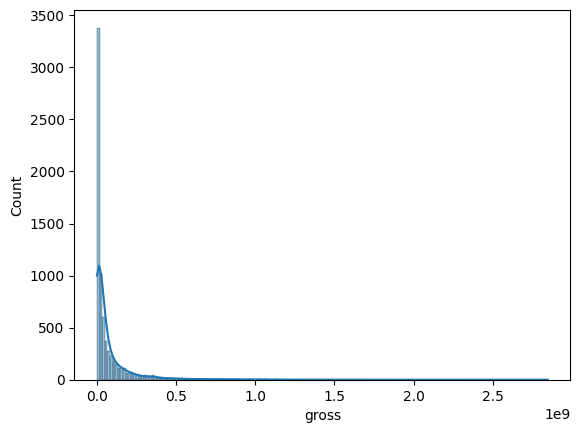

In [15]:
print(df["gross"].skew())
sns.histplot(df["gross"].dropna(), kde=True)

In [16]:
# Same case here that it is highly skewed data
# So now filling the gross with the median
df["gross"] = df["gross"].fillna(df["gross"].median())
# For the text data like company we cannot fill it with any data from our side as it is not a rule that which company might have produced this content
# So to handle these null values I will fill it with UNKNWON
# I cannot leave these values as it is as if I do so they will not be used during plotting or groupby. I don't want to loose data so I will not delete them as well.
df["company"] = df["company"].fillna("UNKNOWN")

In [17]:
df.isna().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [18]:
df["star"]

0        Jack Nicholson
1        Brooke Shields
2           Mark Hamill
3           Robert Hays
4           Chevy Chase
             ...       
7652    Zhi-zhong Huang
7653       Shea Whigham
7656        Scott Pryor
7658        Dan Belcher
7659     Kristina Klebe
Name: star, Length: 7584, dtype: str

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
# As only 1 row is missing so we can drop it
df = df.dropna(subset=["star"])

In [21]:
df.isna().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [22]:
df["profit"] = df["gross"]-df["budget"]

In [23]:
# As votes cannot be a float so I will convert them to integers to save memory
df["votes"] = df["votes"].astype("int")
df["runtime"] = df["runtime"].astype("int")

In [24]:
df.dtypes

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes         int64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime       int64
profit      float64
dtype: object

In [25]:
decades = (df["year"] // 10) * 10
df.insert(loc=4, column="decade", value=decades)

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 7584 entries, 0 to 7659
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7584 non-null   str    
 1   rating    7584 non-null   str    
 2   genre     7584 non-null   str    
 3   year      7584 non-null   int64  
 4   decade    7584 non-null   int64  
 5   released  7584 non-null   str    
 6   score     7584 non-null   float64
 7   votes     7584 non-null   int64  
 8   director  7584 non-null   str    
 9   writer    7584 non-null   str    
 10  star      7584 non-null   str    
 11  country   7584 non-null   str    
 12  budget    7584 non-null   float64
 13  gross     7584 non-null   float64
 14  company   7584 non-null   str    
 15  runtime   7584 non-null   int64  
 16  profit    7584 non-null   float64
dtypes: float64(4), int64(4), str(9)
memory usage: 1.9 MB


In [27]:
df["decade"]

0       1980
1       1980
2       1980
3       1980
4       1980
        ... 
7652    2020
7653    2020
7656    2020
7658    2020
7659    2020
Name: decade, Length: 7584, dtype: int64

### Now I am going to get the genre with highest IMDB average score

In [28]:
average_genre_score = df.groupby("genre")["score"].mean()
# Getting the genre which has maximum IMDb score
average_genre_score.idxmax()

'Musical'

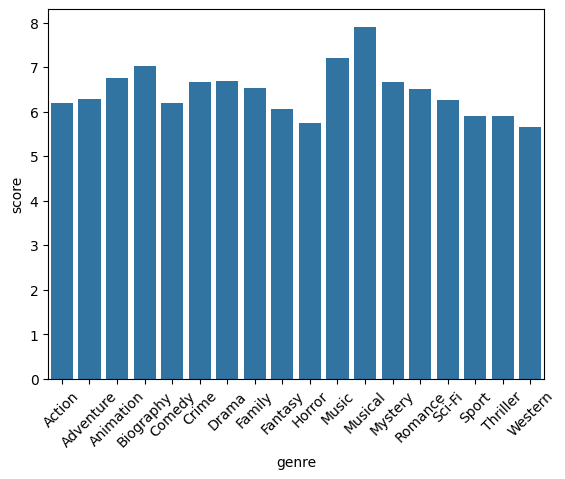

In [29]:
sns.barplot(average_genre_score)
plt.xticks(rotation=45)
plt.show()

In [30]:
print(f"The category with highest average IMDb score is {average_genre_score.idxmax()}")

The category with highest average IMDb score is Musical


### Top 10 Directors by Average Score

In [31]:
# I am doing this because I don't want any director with only one movie which is super-hit to be classified as top director
movie_count = df["director"].value_counts()
qualified_directors = movie_count[movie_count>3].index
average_director_score = df[df["director"].isin(qualified_directors)].groupby(df["director"])["score"].mean()

In [32]:
average_director_score.idxmax()

'Christopher Nolan'

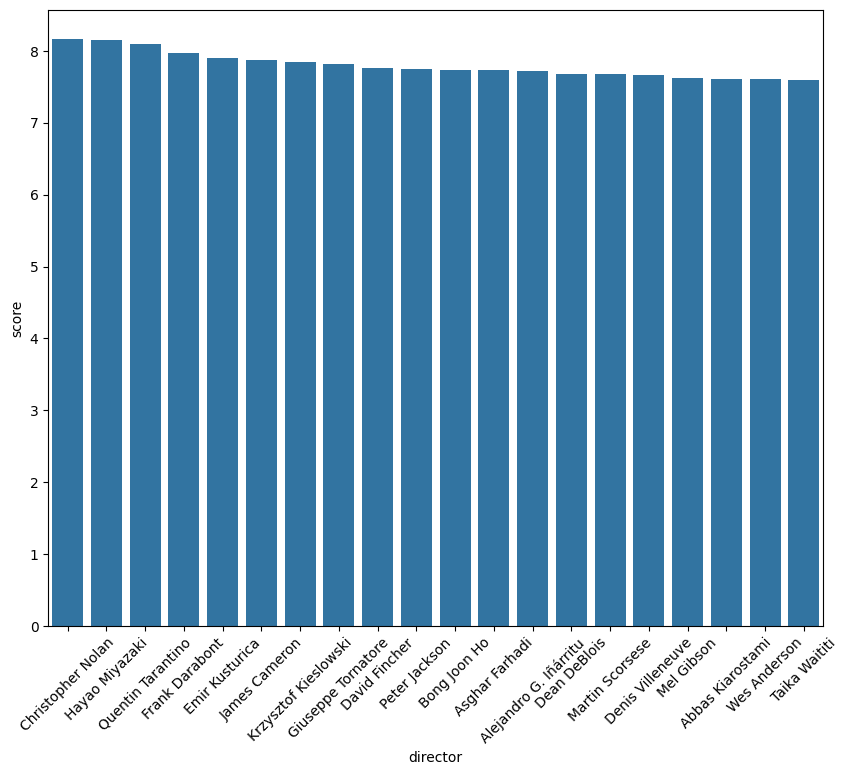

In [33]:
plt.figure(figsize=(10, 8))
sns.barplot(average_director_score.sort_values(ascending=False).head(20))
plt.xticks(rotation=45)
plt.show()

In [34]:
print(f"The top director with highest average IMDb score is {average_director_score.idxmax()}")

The top director with highest average IMDb score is Christopher Nolan


### Does runtime affect scores?

In [35]:
corelation = df["runtime"].corr(df["score"])
print(corelation)

0.40095712322423915


In [36]:
# As we got 0.4 corr that means correlation is not very strong but still runtime and score are positively correlated
# sns.regplot(x=df["runtime"], y=df["score"], line_kws={"color": "red", "lw": 4})
# plt.show()

### Do bigger budgets earn more gross?

In [37]:
print(df["budget"].corr(df["gross"]))

0.7457674384889525


<Axes: xlabel='budget', ylabel='gross'>

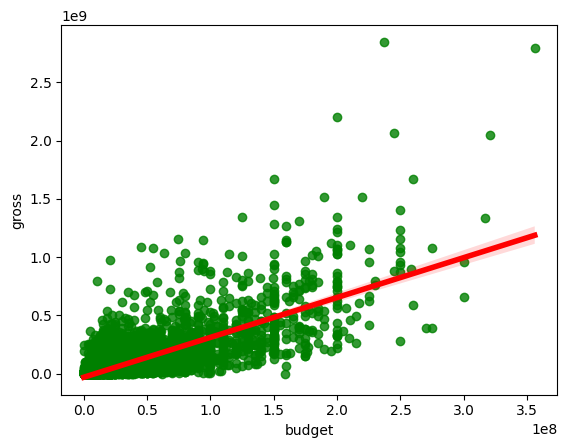

In [38]:
# This value of corr suggests that they are highly and positively co-related
sns.regplot(x=df["budget"], y=df["gross"], color="green", line_kws={"color": "red", "lw": 4})

### Which genre makes the most money on average?

In [39]:
average_genre_gross = df.groupby("genre")["gross"].mean()/1e6
print("Data is in millions")
print(average_genre_gross)

Data is in millions
genre
Action       143.448388
Adventure    108.092747
Animation    239.371570
Biography     47.572599
Comedy        43.968997
Crime         39.480636
Drama         38.599813
Family       215.787648
Fantasy       38.811840
Horror        46.626344
Music          0.110014
Musical        2.217255
Mystery      101.183528
Romance       23.549375
Sci-Fi        31.203657
Sport          1.067629
Thriller      25.287207
Western       10.675295
Name: gross, dtype: float64


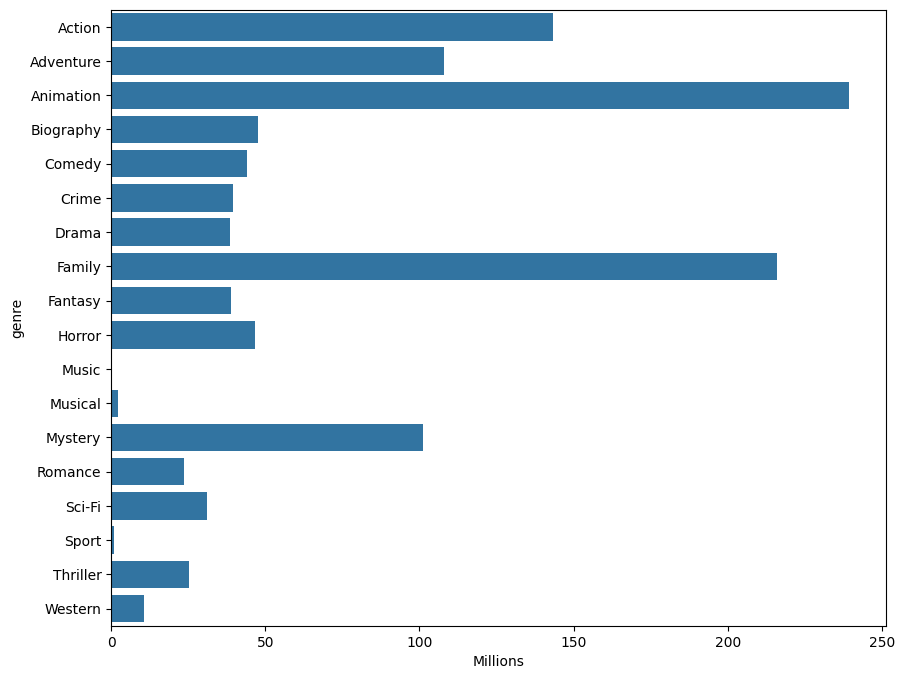

In [40]:
plt.figure(figsize=(10,8))
sns.barplot(x=average_genre_gross.head(30).values, y=average_genre_gross.head(30).index)
plt.xlabel("Millions")
plt.ylabel("genre")
plt.show()

### Which country produces most movies?

In [41]:
movie_count_per_country = df["country"].value_counts().head(15) # I am using head although all countries can be displayed but on scale count will not be visible as the count of movies is very less

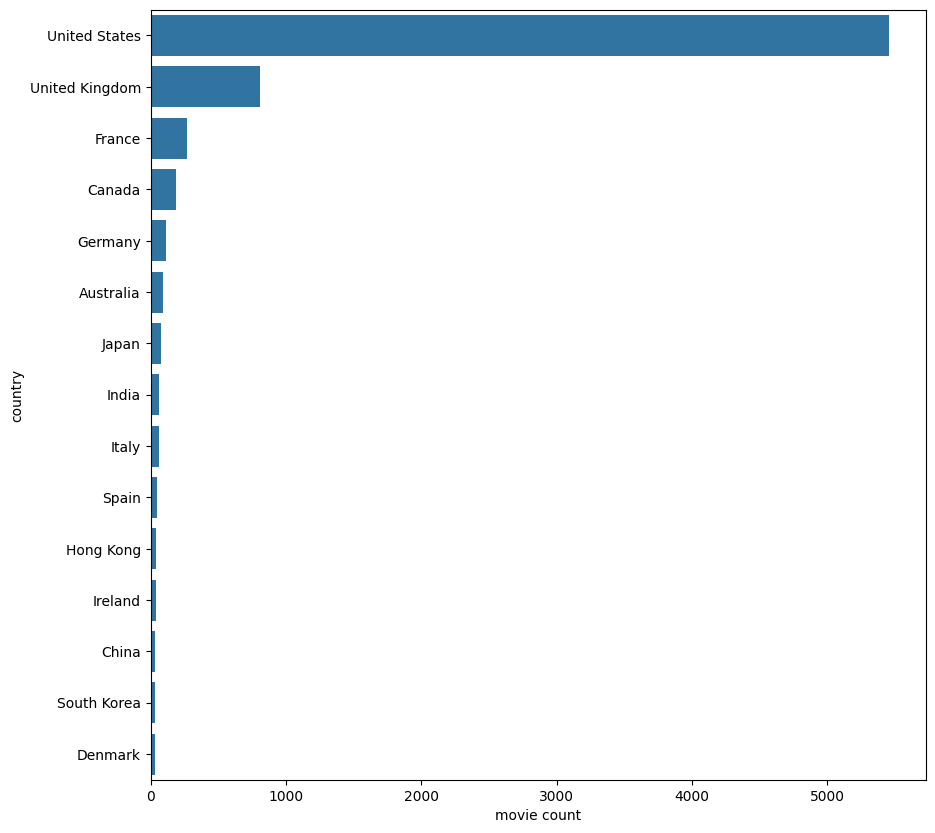

In [42]:
plt.figure(figsize=(10,10))
sns.barplot(y=movie_count_per_country.index, x=movie_count_per_country.values)
plt.xlabel("movie count")
plt.ylabel("country")
plt.show()

### Biggest flop

In [43]:
flop_movie = df.loc[df["profit"].idxmin()]

In [44]:
print(f"The biggest flop movie is {flop_movie["name"]}")

The biggest flop movie is The Irishman


### Most successful movie

In [45]:
success_movie = df.loc[df["profit"].idxmax()]

In [46]:
print(f"The most successful movie is {success_movie["name"]}")

The most successful movie is Avatar


### Best decade quality by highest average score

In [47]:
score_mean_per_decade = df.groupby("decade")["score"].mean()

In [48]:
print(f"The best decade quality by highest average score is {score_mean_per_decade.idxmax()}")

The best decade quality by highest average score is 2010


<Axes: xlabel='decade', ylabel='score'>

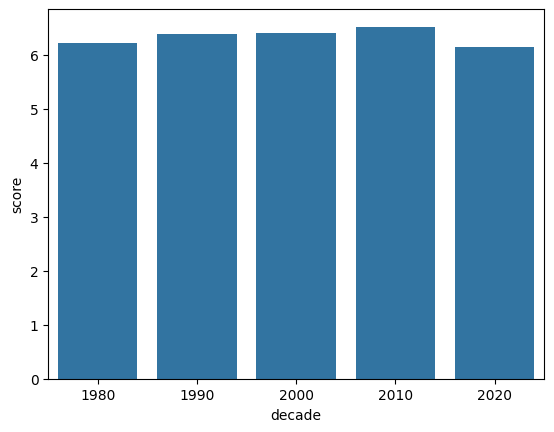

In [49]:
sns.barplot(score_mean_per_decade)